# Ontological Generalization Framework
### TAG Experiment Pipeline

**Local:** Set `USE_COLAB = False` in Cell 1.  
**Colab:** Set `USE_COLAB = True`, mount Drive, upload project files to `MyDrive/tag_project/`.

| Cell | Purpose |
|------|---------|
| 1 | Environment setup (Colab/local toggle) |
| 2 | Imports |
| 3 | `generate_random_subsets` |
| 4 | `OntologicalExperimentPipeline` class |
| 5 | Config |
| 6 | Generate subsets |
| 7 | Smoke test (optional) |
| 8 | Full run |

In [1]:
# ── Cell 1: Environment setup ────────────────────────────────────────────────
USE_COLAB = False  # Set True when running on Google Colab

if USE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/tag_project/'
    import subprocess, sys
    torch_ver = subprocess.check_output(
        [sys.executable, '-c', 'import torch; print(torch.__version__)']
    ).decode().strip()
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
        'sentence-transformers', 'networkx', 'scikit-learn', 'tqdm'])
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
        'torch-scatter', 'torch-sparse', 'torch-cluster',
        'torch-spline-conv', 'torch-geometric',
        '-f', f'https://data.pyg.org/whl/torch-{torch_ver}.html'])
    import sys, os
    sys.path.insert(0, BASE)
    os.chdir(BASE)
else:
    BASE = ''  # local: project files are in the working directory

print(f'BASE = "{BASE}"')
print('Environment ready.')

BASE = ""
Environment ready.


In [2]:
# ── Cell 2: Imports ──────────────────────────────────────────────────────────
import os
import random
import numpy as np
from pathlib import Path
from typing import List, Dict
from datetime import datetime
import torch
import math
import csv
import pandas as pd
from collections import Counter
from sklearn.preprocessing import normalize
from tqdm import tqdm

from data_manager import ArxivDataManager
from constructor import TAGBuilder, TAGConfiguration
from models import ModelFactory
from trainer import TrainingPipeline, PerformanceTracker
from analyzer import DecisionTreeAnalyzer

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

c:\Users\amkah\anaconda3\envs\tag_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.10.0+cpu
CUDA available: False


In [3]:
# ── Cell 3: Subset generator ─────────────────────────────────────────────────
def generate_random_subsets(
    json_path: str,
    n_subsets: int = 8,
    subset_size: int = 10000,
    output_dir: str = 'data/subsets',
    seed: int = 42
) -> List[str]:
    """
    Generate n random non-overlapping subsets from the full arxiv snapshot.
    Single pass through source file. Skips generation if all files already exist.
    """
    os.makedirs(output_dir, exist_ok=True)
    existing = [os.path.join(output_dir, f'subset_{i:02d}.jsonl') for i in range(n_subsets)]
    if all(os.path.exists(p) for p in existing):
        print(f'All {n_subsets} subsets already exist, skipping generation.')
        return existing

    print(f'Counting total records in {json_path}...')
    total = sum(1 for _ in open(json_path, 'r', encoding='utf-8'))
    print(f'Total records: {total:,}')

    required = n_subsets * subset_size
    if required > total:
        raise ValueError(
            f'Need {required:,} records for {n_subsets} non-overlapping subsets '
            f'of {subset_size}, but only {total:,} available.'
        )

    random.seed(seed)
    all_indices = random.sample(range(total), required)
    index_sets = [
        set(all_indices[i * subset_size:(i + 1) * subset_size])
        for i in range(n_subsets)
    ]

    subset_records = [[] for _ in range(n_subsets)]
    print('Reading file in single pass...')
    with open(json_path, 'r', encoding='utf-8') as f:
        for line_idx, line in enumerate(tqdm(f, total=total)):
            for subset_idx, index_set in enumerate(index_sets):
                if line_idx in index_set:
                    subset_records[subset_idx].append(line)
                    break

    subset_paths = []
    for i, records in enumerate(subset_records):
        subset_path = os.path.join(output_dir, f'subset_{i:02d}.jsonl')
        with open(subset_path, 'w', encoding='utf-8') as f:
            f.writelines(records)
        os.makedirs(os.path.join(output_dir, f'embeddings_{i:02d}'), exist_ok=True)
        subset_paths.append(subset_path)
        print(f'Subset {i:02d}: {len(records)} records saved.')

    print(f'Generated {n_subsets} subsets of {subset_size} records each.')
    return subset_paths

In [4]:
# ── Cell 4: OntologicalExperimentPipeline ────────────────────────────────────
class OntologicalExperimentPipeline:
    """Complete pipeline for running ontological experiments."""

    def __init__(self, config: Dict):
        self.config = config
        self.data_manager = None
        self.tag_builder = None
        self.analyzer = DecisionTreeAnalyzer()
        self.performance_tracker = PerformanceTracker()

    def setup_data(self):
        print('\n' + '='*80)
        print('STEP 1: DATA LOADING AND PREPROCESSING')
        print('='*80)
        self.data_manager = ArxivDataManager(
            data_path=self.config['data_path'],
            subset_size=self.config.get('subset_size', None)
        )
        self.data_manager.load_data()
        self.data_manager.extract_unique_authors()
        if self.config.get('use_precomputed_embeddings', False):
            self.data_manager.load_embeddings(
                input_dir=self.config['embedding_dir'],
                prefix=self.config.get('embedding_prefix', '')
            )
        else:
            self.data_manager.compute_embeddings(
                model_name=self.config.get('sbert_model', 'all-MiniLM-L6-v2'),
                text_fidelity='super',
                force_recompute=self.config.get('force_recompute', False)
            )
            if self.config.get('save_embeddings', True):
                self.data_manager.save_embeddings(
                    output_dir=self.config['embedding_dir'],
                    prefix=self.config.get('embedding_prefix', '')
                )
        self.tag_builder = TAGBuilder(self.data_manager)
        print('\n✅ Data setup complete\n')

    def define_ontological_space(self) -> List[Dict]:
        experiment_space = []
        task_indices = self.config.get('task_indices', [1])
        node_indices = self.config.get('node_indices', [7, 8])
        edge_indices = self.config.get('edge_indices', [10, 11])
        text_indices = self.config.get('text_indices', ['a', 'e'])
        similarity_thresholds = self.config.get('similarity_thresholds', ['a', 'c'])
        for task_idx in task_indices:
            for node_idx in node_indices:
                for edge_idx in edge_indices:
                    for text_idx in text_indices:
                        if edge_idx == 11:
                            for threshold in similarity_thresholds:
                                experiment_space.append({
                                    'task_idx': task_idx, 'node_idx': node_idx,
                                    'edge_idx': edge_idx, 'text_idx': text_idx,
                                    'similarity_threshold': threshold
                                })
                        else:
                            experiment_space.append({
                                'task_idx': task_idx, 'node_idx': node_idx,
                                'edge_idx': edge_idx, 'text_idx': text_idx,
                                'similarity_threshold': None
                            })
        print(f"\n{'='*80}")
        print(f"ONTOLOGICAL EXPERIMENT SPACE: {len(experiment_space)} variants")
        print(f"{'='*80}")
        print(f"Tasks: {task_indices} | Nodes: {node_indices} | Edges: {edge_indices}")
        print(f"Text: {text_indices} | Thresholds: {similarity_thresholds}")
        print(f"{'='*80}\n")
        return experiment_space

    def run_experiment(self, exp_config: Dict) -> Dict:
        tag = self.tag_builder.build(
            task_idx=exp_config['task_idx'], node_idx=exp_config['node_idx'],
            edge_idx=exp_config['edge_idx'], text_idx=exp_config['text_idx'],
            similarity_threshold=exp_config['similarity_threshold']
        )
        num_classes = self.data_manager.num_classes or self.config.get('num_classes', 10)
        task_idx = exp_config['task_idx']
        if exp_config['node_idx'] == 8:
            embeddings = self.data_manager.author_embeddings
            node_list = self.data_manager.author_list
            node_type = 'author'
        else:
            embeddings = self.data_manager.article_embeddings
            node_list = list(self.data_manager.df['id'])
            node_type = 'paper'

        if task_idx == 1:
            if node_type == 'author':
                labels = self.data_manager.get_author_category_labels(num_classes=num_classes)
            else:
                labels = self.data_manager.get_category_labels(num_classes=num_classes)
            output_dimension = num_classes
            stats_task_type = 'node_categorical'
        elif task_idx == 2:
            if node_type == 'author':
                labels = self.data_manager.get_author_scalar_labels(tag.graph)
            else:
                labels = self.data_manager.get_paper_scalar_labels(tag.graph)
            output_dimension = 1
            stats_task_type = 'node_scalar'
        elif task_idx == 3:
            labels = self.data_manager.get_edge_category_labels(tag.graph, node_type=node_type)
            output_dimension = 2
            stats_task_type = 'edge_categorical'
        else:
            raise NotImplementedError(f'Task {task_idx} is not implemented in this pipeline.')
        embeddings = normalize(embeddings, axis=1).astype(np.float32)
        def model_factory(**kwargs):
            # pop model_type from kwargs if present to avoid duplicate kwarg
            kwargs.pop('model_type', None)
            return ModelFactory.create_model(
                model_type=self.config.get('model_type', 'sage'), **kwargs
            )
        pipeline = TrainingPipeline(
            model_factory=model_factory,
            device=self.config.get('device', 'cuda' if torch.cuda.is_available() else 'cpu')
        )
        model_config = {
            'hidden_dim': self.config.get('hidden_dim', 256),
            'dropout': self.config.get('dropout', 0.5)
        }
        trainer_config = {
            'lr': self.config.get('lr', 0.001),
            'weight_decay': self.config.get('weight_decay', 5e-4),
            'epochs': self.config.get('epochs', 100),
            'patience': self.config.get('patience', 50)
        }
        save_model_path = None
        if self.config.get('save_models', False):
            save_model_path = str(
                Path(self.config['output_dir']) / 'models' / f"model_{tag.get_identifier()}.pt"
            )
            Path(save_model_path).parent.mkdir(exist_ok=True, parents=True)
        # Epoch log — one shared CSV per subset run, appended per experiment
        epoch_log_path = None
        if self.config.get('save_training_history', False):
            epoch_log_path = str(
                Path(self.config['output_dir']) / 'analysis' / 'epoch_log.csv'
            )
        results = pipeline.run_experiment(
            tag=tag, embeddings=embeddings, labels=labels,
            node_list=node_list, num_classes=output_dimension,
            model_config=model_config, trainer_config=trainer_config,
            save_model_path=save_model_path,
            save_training_history=self.config.get('save_training_history', False),
            epoch_log_path=epoch_log_path,
        )
        G = tag.graph
        all_words = []
        for row in self.data_manager.df.itertuples():
            text = f"{getattr(row, 'title', '') or ''} {getattr(row, 'abstract', '') or ''}"
            all_words.extend(text.lower().split())
        counts = Counter(all_words)
        total_words = sum(counts.values())
        text_vocab_entropy = -sum(
            (c / total_words) * math.log2(c / total_words) for c in counts.values()
        )
        label_counts = self.data_manager.df['cat_top'].value_counts()
        label_probs = label_counts / label_counts.sum()
        label_balance_entropy = -sum(p * math.log2(p) for p in label_probs)
        avg_text_length = np.mean([
            len(str(getattr(row, 'title', '') or '')) + len(str(getattr(row, 'abstract', '') or ''))
            for row in self.data_manager.df.itertuples()
        ])
        results['stats'] = {
            'number_of_nodes': G.number_of_nodes(),
            'avg_text_length': round(float(avg_text_length), 4),
            'text_vocab_entropy': text_vocab_entropy,
            'label_balance_entropy': float(label_balance_entropy),
            'task_type': stats_task_type,
            'output_dimension': output_dimension,
            'normalized_score': float(results['test_metrics'].get('top1', results['test_metrics'].get('accuracy', results['test_metrics'].get('r2', float('nan'))))),
        }
        return results

    def run_all_experiments(self):
        print('\n' + '='*80)
        print('STEP 2: RUNNING ONTOLOGICAL EXPERIMENTS')
        print('='*80)
        experiment_space = self.define_ontological_space()
        for i, exp_config in enumerate(experiment_space):
            print(f"\n{'#'*80}")
            print(f"EXPERIMENT {i+1}/{len(experiment_space)}")
            print(f"{'#'*80}")
            try:
                results = self.run_experiment(exp_config)
                self.performance_tracker.add_result(results)
                # Stream to CSV
                stream_path = Path(self.config['output_dir']) / 'analysis' / 'results_stream.csv'
                stream_path.parent.mkdir(exist_ok=True, parents=True)
                row = {
                    'Task_Idx': exp_config['task_idx'],
                    'Node_Idx': exp_config['node_idx'],
                    'Edge_Idx': exp_config['edge_idx'],
                    'Text_Idx': exp_config['text_idx'],
                    'Similarity_Threshold': exp_config.get('similarity_threshold', ''),
                    **results['test_metrics'],
                    **results.get('stats', {})
                }
                write_header = not stream_path.exists()
                with open(stream_path, 'a', newline='') as f:
                    writer = csv.DictWriter(f, fieldnames=row.keys())
                    if write_header:
                        writer.writeheader()
                    writer.writerow(row)
                self.analyzer.add_experiment(
                    task_idx=exp_config['task_idx'],
                    node_idx=exp_config['node_idx'],
                    edge_idx=exp_config['edge_idx'],
                    text_idx=exp_config['text_idx'],
                    test_metrics=results['test_metrics'],
                    stats=results.get('stats', None)
                )
            except Exception as e:
                print(f'⚠ Experiment {i+1} failed: {e}')
                continue
        print('\n✅ All experiments complete\n')

    def analyze_results(self):
        print('\n' + '='*80)
        print('STEP 3: META-ANALYSIS')
        print('='*80)
        self.analyzer.build_decision_tree_table()
        self.analyzer.analyze_best_configurations(top_k=self.config.get('top_k', 5))
        self.analyzer.analyze_by_ontology()
        analysis_dir = Path(self.config['output_dir']) / 'analysis'
        self.analyzer.save_analysis(str(analysis_dir))
        self.performance_tracker.save_results(str(analysis_dir / 'all_results.json'))
        if len(self.analyzer.dt_table) >= 5:
            self.analyzer.train_decision_tree(
                target_metric='Performance_Band',
                max_depth=self.config.get('dt_max_depth', 5),
                min_samples_split=self.config.get('dt_min_samples_split', 5)
            )
            if self.config.get('plot_decision_tree', True):
                try:
                    plot_path = analysis_dir / 'decision_tree.png'
                    self.analyzer.plot_decision_tree(save_path=str(plot_path))
                    print(f'✅ Decision tree saved to {plot_path}')
                except Exception as e:
                    print(f'⚠ Decision tree plot failed: {e}')
        print('\n✅ Meta-analysis complete\n')

    def run(self):
        print('\n' + '='*80)
        print('ONTOLOGICAL GENERALIZATION FRAMEWORK')
        print(f"Subset: {self.config['data_path']}")
        print('='*80)
        self.setup_data()
        self.run_all_experiments()
        self.analyze_results()
        print('\n' + '='*80 + '\nPIPELINE COMPLETE\n' + '='*80)


In [12]:
# ── Cell 5: Config ───────────────────────────────────────────────────────────
run_id = datetime.now().strftime('%Y%m%d_%H%M%S')

BASE_CONFIG = {
    'subset_size': None,

    # Ontological space
    'task_indices': [1,2,3],
    'node_indices': [7, 8],
    'edge_indices': [10, 11],
    'text_indices': ['a', 'e'],           # best and worst text fidelity
    'similarity_thresholds': ['a', 'c'],  # 0.60 and 0.90

    # Model
    'model_type': 'sage',
    'hidden_dim': 256,
    'dropout': 0.5,

    # Training
    'lr': 0.001,
    'weight_decay': 5e-4,
    'epochs': 100,
    'patience': 50,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',

    # Output
    'save_models': False,
    'save_training_history': True,  # set True to write epoch_log.csv
    'dt_max_depth': 8,
    'dt_min_samples_split': 8,
    'plot_decision_tree': True,
    'top_k': 5,
    'use_precomputed_embeddings': True,
    'save_embeddings': True,
}

N_SUBSETS = 2
SUBSET_SIZE = 1_000
SOURCE_DATA = BASE + 'data/arxiv_subset_200k.jsonl'
SUBSETS_DIR = BASE + 'data/subsets'

print(f'Run ID: {run_id}')
print(f'Device: {BASE_CONFIG["device"]}')
print(f'Epochs: {BASE_CONFIG["epochs"]}')
print(f'Epoch logging: {BASE_CONFIG["save_training_history"]}')
print(f'Source data: {SOURCE_DATA}')

Run ID: 20260323_113858
Device: cpu
Epochs: 100
Epoch logging: True
Source data: data/arxiv_subset_200k.jsonl


In [6]:
# ── Cell 6: Generate subsets ─────────────────────────────────────────────────
# Safe to re-run — skips generation if files already exist
subset_paths = generate_random_subsets(
    json_path=SOURCE_DATA,
    n_subsets=N_SUBSETS,
    subset_size=SUBSET_SIZE,
    output_dir=SUBSETS_DIR,
    seed=42
)
print('\nSubset paths:')
for p in subset_paths:
    print(f'  {p}')

All 2 subsets already exist, skipping generation.

Subset paths:
  data/subsets\subset_00.jsonl
  data/subsets\subset_01.jsonl


In [ ]:
# ── Cell 7: Smoke test (optional) ────────────────────────────────────────────
# 1 experiment, 5 epochs — verify imports, paths, and GPU before full run.
# Uncomment to use.

smoke_config = {
    **BASE_CONFIG,
    'data_path': subset_paths[0],
    'embedding_dir': f'{SUBSETS_DIR}/embeddings_00',
    'output_dir': f'{BASE}output/run_{run_id}/smoke_test',
    'task_indices': [1, 2, 3],
    'node_indices': [7, 8],
    'edge_indices': [10],
    'text_indices': ['a'],
    'similarity_thresholds': ['b'],
    'epochs': 5,
    'save_training_history': True,  # test epoch log too
}
OntologicalExperimentPipeline(smoke_config).run()

print('Uncomment above to run smoke test.')


SUBSET RUN 1/2  —  data/subsets\subset_00.jsonl

ONTOLOGICAL GENERALIZATION FRAMEWORK
Subset: data/subsets\subset_00.jsonl

STEP 1: DATA LOADING AND PREPROCESSING
Loading data from data\subsets\subset_00.jsonl...
Parsing categories...
Category mapping: {'astro-ph': 0, 'cond-mat': 1, 'cs': 2, 'gr-qc': 3, 'hep-ex': 4, 'hep-lat': 5, 'hep-ph': 6, 'hep-th': 7, 'math': 8, 'math-ph': 9, 'nlin': 10, 'nucl-ex': 11, 'nucl-th': 12, 'physics': 13, 'q-bio': 14, 'q-fin': 15, 'quant-ph': 16, 'stat': 17}
NUM_CLASSES = 18
✅ Loaded 1000 articles with 18 categories
Category distribution:
cat_top
math        196
astro-ph    173
cond-mat    171
physics      74
cs           72
quant-ph     62
hep-th       56
hep-ph       51
gr-qc        35
nucl-th      19
Name: count, dtype: int64


Extracting authors: 100%|██████████| 1000/1000 [00:00<00:00, 184543.47it/s]


Computing author category labels...
✅ Found 3527 unique authors
✅ 3527 authors have category labels
✅ Loaded embeddings from data\subsets\embeddings_00

✅ Data setup complete


STEP 2: RUNNING ONTOLOGICAL EXPERIMENTS

ONTOLOGICAL EXPERIMENT SPACE: 36 variants
Tasks: [1, 2, 3] | Nodes: [7, 8] | Edges: [10, 11]
Text: ['a', 'e'] | Thresholds: ['a', 'c']


################################################################################
EXPERIMENT 1/36
################################################################################

Building TAG: Task=1, Node=paper, Edge=coauthorship, Text=super


Adding coauthorship edges: 100%|██████████| 1000/1000 [00:00<00:00, 5457.32it/s]


✅ Coauthorship graph: 1000 nodes, 34 edges
✅ Generated paper labels: (1000, 18), 1000.0 nodes with labels

############################################################
Experiment: T1_N7_E10_Xa
############################################################

Training on device: cpu
Epochs: 100, LR: 0.001, Weight Decay: 0.0005

Epoch 001 | Loss 3.0056 | Train KL 2.9040 | Val KL 2.9028 | Val top1 0.054 | Val cos 0.233
Epoch 010 | Loss 2.0327 | Train KL 2.7356 | Val KL 2.7330 | Val top1 0.272 | Val cos 0.276
Epoch 020 | Loss 1.4107 | Train KL 2.2814 | Val KL 2.2761 | Val top1 0.513 | Val cos 0.432
Epoch 030 | Loss 1.0528 | Train KL 1.8898 | Val KL 1.8854 | Val top1 0.718 | Val cos 0.564
Epoch 040 | Loss 0.7786 | Train KL 1.3128 | Val KL 1.3086 | Val top1 0.790 | Val cos 0.735
Epoch 050 | Loss 0.5892 | Train KL 0.7372 | Val KL 0.7353 | Val top1 0.854 | Val cos 0.856
Epoch 060 | Loss 0.4405 | Train KL 0.4233 | Val KL 0.4263 | Val top1 0.889 | Val cos 0.907
Epoch 070 | Loss 0.3337 | Train KL 0.2

...

✅ Similarity graph (threshold=0.9): 3527 nodes, 12278 edges
✅ Edge labels: 12278 edges, 12278 valid, 0 cross-category (0.0%)

############################################################
Experiment: T3_N8_E11_Xa_Sc
############################################################

Training on device: cpu
Epochs: 100, LR: 0.001, Weight Decay: 0.0005

Epoch 001 | Loss 0.8786 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 010 | Loss 0.0007 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 020 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 030 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 040 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 050 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 060 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 070 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 080 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.

Adding similarity edges: 100%|██████████| 3527/3527 [00:00<00:00, 72112.89it/s]


✅ Similarity graph (threshold=0.6): 3527 nodes, 15188 edges
✅ Edge labels: 15188 edges, 15188 valid, 465 cross-category (3.1%)

############################################################
Experiment: T3_N8_E11_Xe_Sa
############################################################

Training on device: cpu
Epochs: 100, LR: 0.001, Weight Decay: 0.0005

Epoch 001 | Loss 0.5794 | Train Acc 0.970 | Val Acc 0.971 | Val F1 0.000
Epoch 010 | Loss 0.0766 | Train Acc 0.970 | Val Acc 0.971 | Val F1 0.000
Epoch 020 | Loss 0.0587 | Train Acc 0.970 | Val Acc 0.971 | Val F1 0.000
Epoch 030 | Loss 0.0508 | Train Acc 0.970 | Val Acc 0.971 | Val F1 0.000
Epoch 040 | Loss 0.0477 | Train Acc 0.970 | Val Acc 0.971 | Val F1 0.000
Epoch 050 | Loss 0.0460 | Train Acc 0.970 | Val Acc 0.971 | Val F1 0.000
Epoch 060 | Loss 0.0452 | Train Acc 0.970 | Val Acc 0.971 | Val F1 0.000
Epoch 070 | Loss 0.0441 | Train Acc 0.970 | Val Acc 0.971 | Val F1 0.000
Epoch 080 | Loss 0.0439 | Train Acc 0.970 | Val Acc 0.971 | Val F1 

Adding similarity edges: 100%|██████████| 3527/3527 [00:00<00:00, 73957.31it/s]


✅ Similarity graph (threshold=0.9): 3527 nodes, 12278 edges
✅ Edge labels: 12278 edges, 12278 valid, 0 cross-category (0.0%)

############################################################
Experiment: T3_N8_E11_Xe_Sc
############################################################

Training on device: cpu
Epochs: 100, LR: 0.001, Weight Decay: 0.0005

Epoch 001 | Loss 0.6646 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 010 | Loss 0.0004 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 020 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 030 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 040 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 050 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 060 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 070 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 080 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.

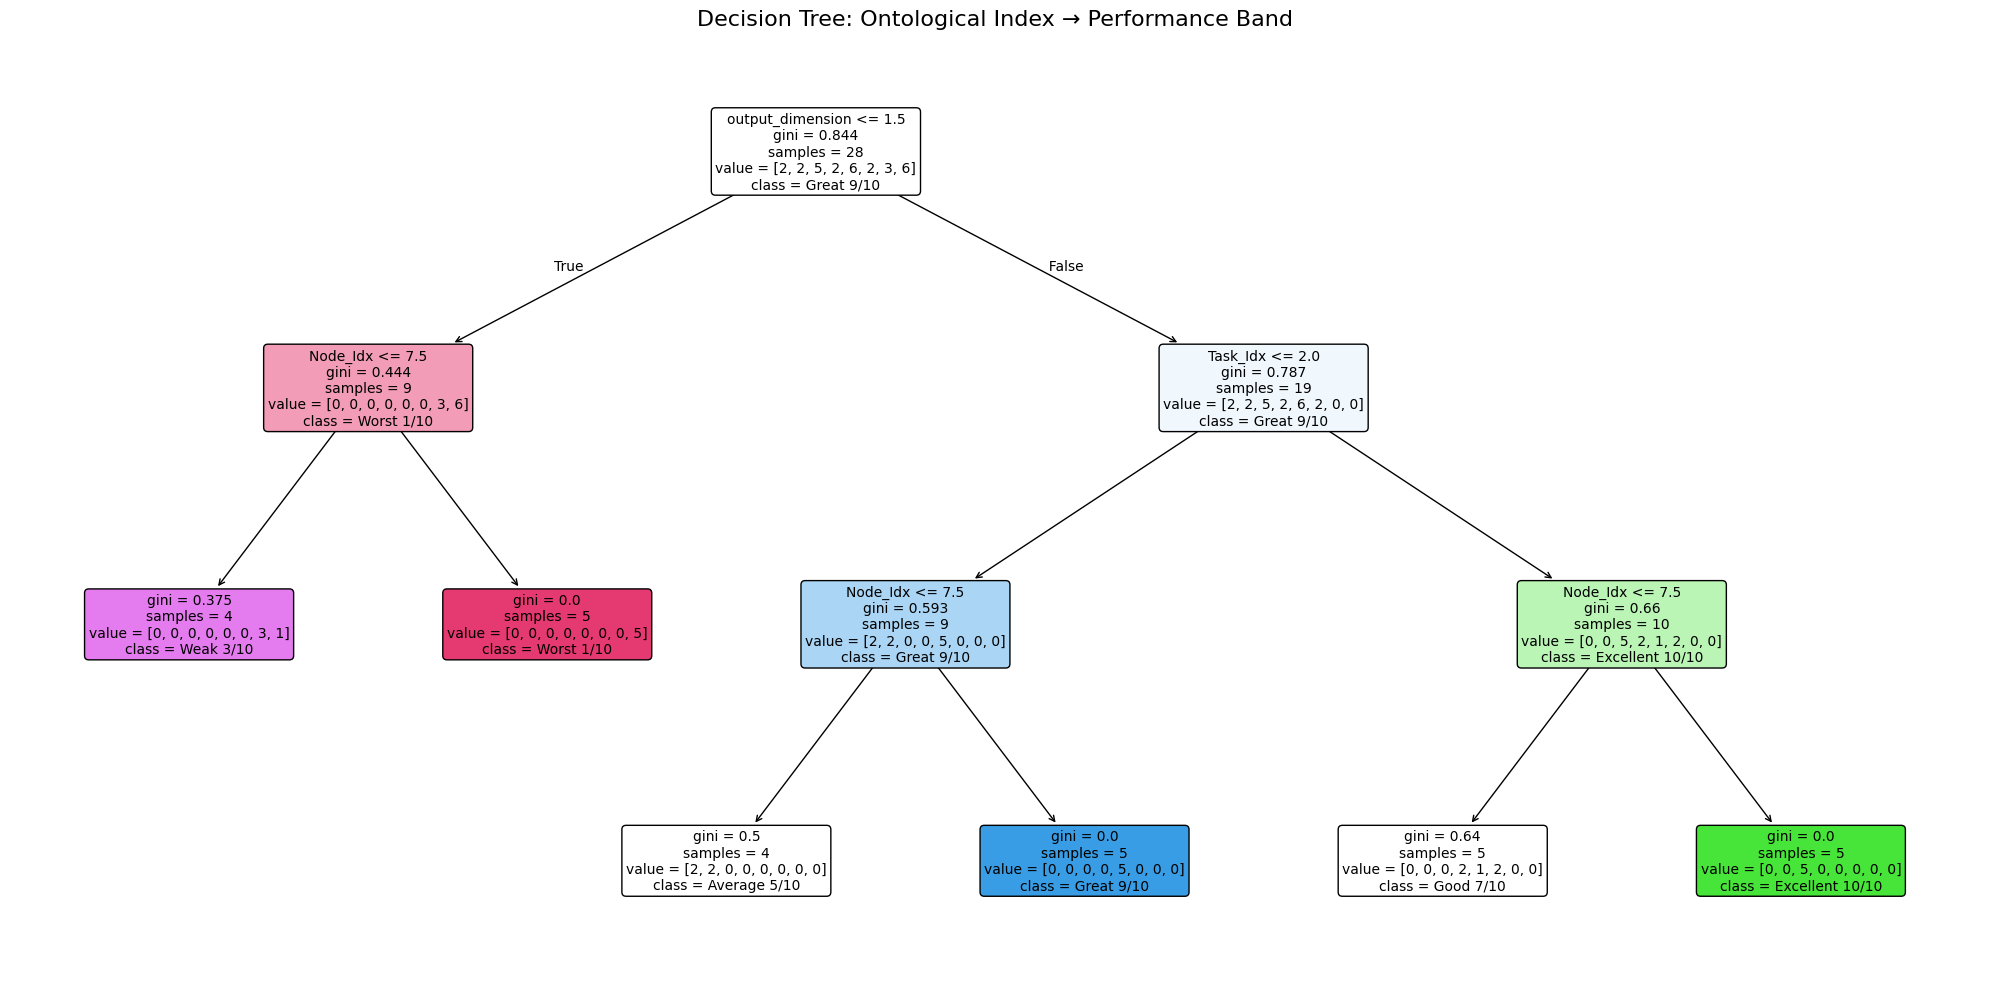

✅ Decision tree saved to output\run_20260323_113858\subset_00\analysis\decision_tree.png

✅ Meta-analysis complete


PIPELINE COMPLETE

SUBSET RUN 2/2  —  data/subsets\subset_01.jsonl

ONTOLOGICAL GENERALIZATION FRAMEWORK
Subset: data/subsets\subset_01.jsonl

STEP 1: DATA LOADING AND PREPROCESSING
Loading data from data\subsets\subset_01.jsonl...
Parsing categories...
Category mapping: {'astro-ph': 0, 'cond-mat': 1, 'cs': 2, 'gr-qc': 3, 'hep-ex': 4, 'hep-lat': 5, 'hep-ph': 6, 'hep-th': 7, 'math': 8, 'math-ph': 9, 'nlin': 10, 'nucl-ex': 11, 'nucl-th': 12, 'physics': 13, 'q-bio': 14, 'q-fin': 15, 'quant-ph': 16, 'stat': 17}
NUM_CLASSES = 18
✅ Loaded 1000 articles with 18 categories
Category distribution:
cat_top
math        200
cond-mat    187
astro-ph    148
hep-ph       75
quant-ph     69
cs           64
physics      58
hep-th       54
gr-qc        36
math-ph      21
Name: count, dtype: int64


Extracting authors: 100%|██████████| 1000/1000 [00:00<00:00, 121338.39it/s]


Computing author category labels...
✅ Found 2989 unique authors
✅ 2989 authors have category labels
✅ Loaded embeddings from data\subsets\embeddings_01

✅ Data setup complete


STEP 2: RUNNING ONTOLOGICAL EXPERIMENTS

ONTOLOGICAL EXPERIMENT SPACE: 36 variants
Tasks: [1, 2, 3] | Nodes: [7, 8] | Edges: [10, 11]
Text: ['a', 'e'] | Thresholds: ['a', 'c']


################################################################################
EXPERIMENT 1/36
################################################################################

Building TAG: Task=1, Node=paper, Edge=coauthorship, Text=super


Adding coauthorship edges: 100%|██████████| 1000/1000 [00:00<00:00, 4712.65it/s]


✅ Coauthorship graph: 1000 nodes, 48 edges
✅ Generated paper labels: (1000, 18), 1000.0 nodes with labels

############################################################
Experiment: T1_N7_E10_Xa
############################################################

Training on device: cpu
Epochs: 100, LR: 0.001, Weight Decay: 0.0005

Epoch 001 | Loss 2.8665 | Train KL 2.8798 | Val KL 2.8803 | Val top1 0.018 | Val cos 0.238
Epoch 010 | Loss 1.8781 | Train KL 2.6198 | Val KL 2.6194 | Val top1 0.351 | Val cos 0.308
Epoch 020 | Loss 1.3048 | Train KL 2.2194 | Val KL 2.2195 | Val top1 0.588 | Val cos 0.442
Epoch 030 | Loss 0.9677 | Train KL 1.8431 | Val KL 1.8494 | Val top1 0.731 | Val cos 0.573
Epoch 040 | Loss 0.7177 | Train KL 1.2729 | Val KL 1.2841 | Val top1 0.834 | Val cos 0.751
Epoch 050 | Loss 0.5389 | Train KL 0.7187 | Val KL 0.7275 | Val top1 0.886 | Val cos 0.868
Epoch 060 | Loss 0.4040 | Train KL 0.3938 | Val KL 0.3995 | Val top1 0.913 | Val cos 0.920
Epoch 070 | Loss 0.3281 | Train KL 0.2

...

✅ Similarity graph (threshold=0.9): 2989 nodes, 8045 edges
✅ Edge labels: 8045 edges, 8045 valid, 0 cross-category (0.0%)

############################################################
Experiment: T3_N8_E11_Xa_Sc
############################################################

Training on device: cpu
Epochs: 100, LR: 0.001, Weight Decay: 0.0005

Epoch 001 | Loss 0.6378 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 010 | Loss 0.0004 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 020 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 030 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 040 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 050 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 060 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 070 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 080 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000

Adding similarity edges: 100%|██████████| 2989/2989 [00:00<00:00, 49277.64it/s]


✅ Similarity graph (threshold=0.6): 2989 nodes, 10549 edges
✅ Edge labels: 10549 edges, 10549 valid, 457 cross-category (4.3%)

############################################################
Experiment: T3_N8_E11_Xe_Sa
############################################################

Training on device: cpu
Epochs: 100, LR: 0.001, Weight Decay: 0.0005

Epoch 001 | Loss 0.7707 | Train Acc 0.957 | Val Acc 0.959 | Val F1 0.000
Epoch 010 | Loss 0.1061 | Train Acc 0.957 | Val Acc 0.959 | Val F1 0.000
Epoch 020 | Loss 0.0816 | Train Acc 0.957 | Val Acc 0.959 | Val F1 0.000
Epoch 030 | Loss 0.0746 | Train Acc 0.957 | Val Acc 0.959 | Val F1 0.000
Epoch 040 | Loss 0.0690 | Train Acc 0.957 | Val Acc 0.959 | Val F1 0.000
Epoch 050 | Loss 0.0684 | Train Acc 0.957 | Val Acc 0.959 | Val F1 0.000
Epoch 060 | Loss 0.0656 | Train Acc 0.960 | Val Acc 0.960 | Val F1 0.486
Epoch 070 | Loss 0.0628 | Train Acc 0.969 | Val Acc 0.970 | Val F1 0.663
Epoch 080 | Loss 0.0595 | Train Acc 0.975 | Val Acc 0.976 | Val F1 

Adding similarity edges: 100%|██████████| 2989/2989 [00:00<00:00, 3061.51it/s]


✅ Similarity graph (threshold=0.9): 2989 nodes, 8045 edges
✅ Edge labels: 8045 edges, 8045 valid, 0 cross-category (0.0%)

############################################################
Experiment: T3_N8_E11_Xe_Sc
############################################################

Training on device: cpu
Epochs: 100, LR: 0.001, Weight Decay: 0.0005

Epoch 001 | Loss 0.8149 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 010 | Loss 0.0006 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 020 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 030 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 040 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 050 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 060 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 070 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000
Epoch 080 | Loss 0.0000 | Train Acc 1.000 | Val Acc 1.000 | Val F1 0.000

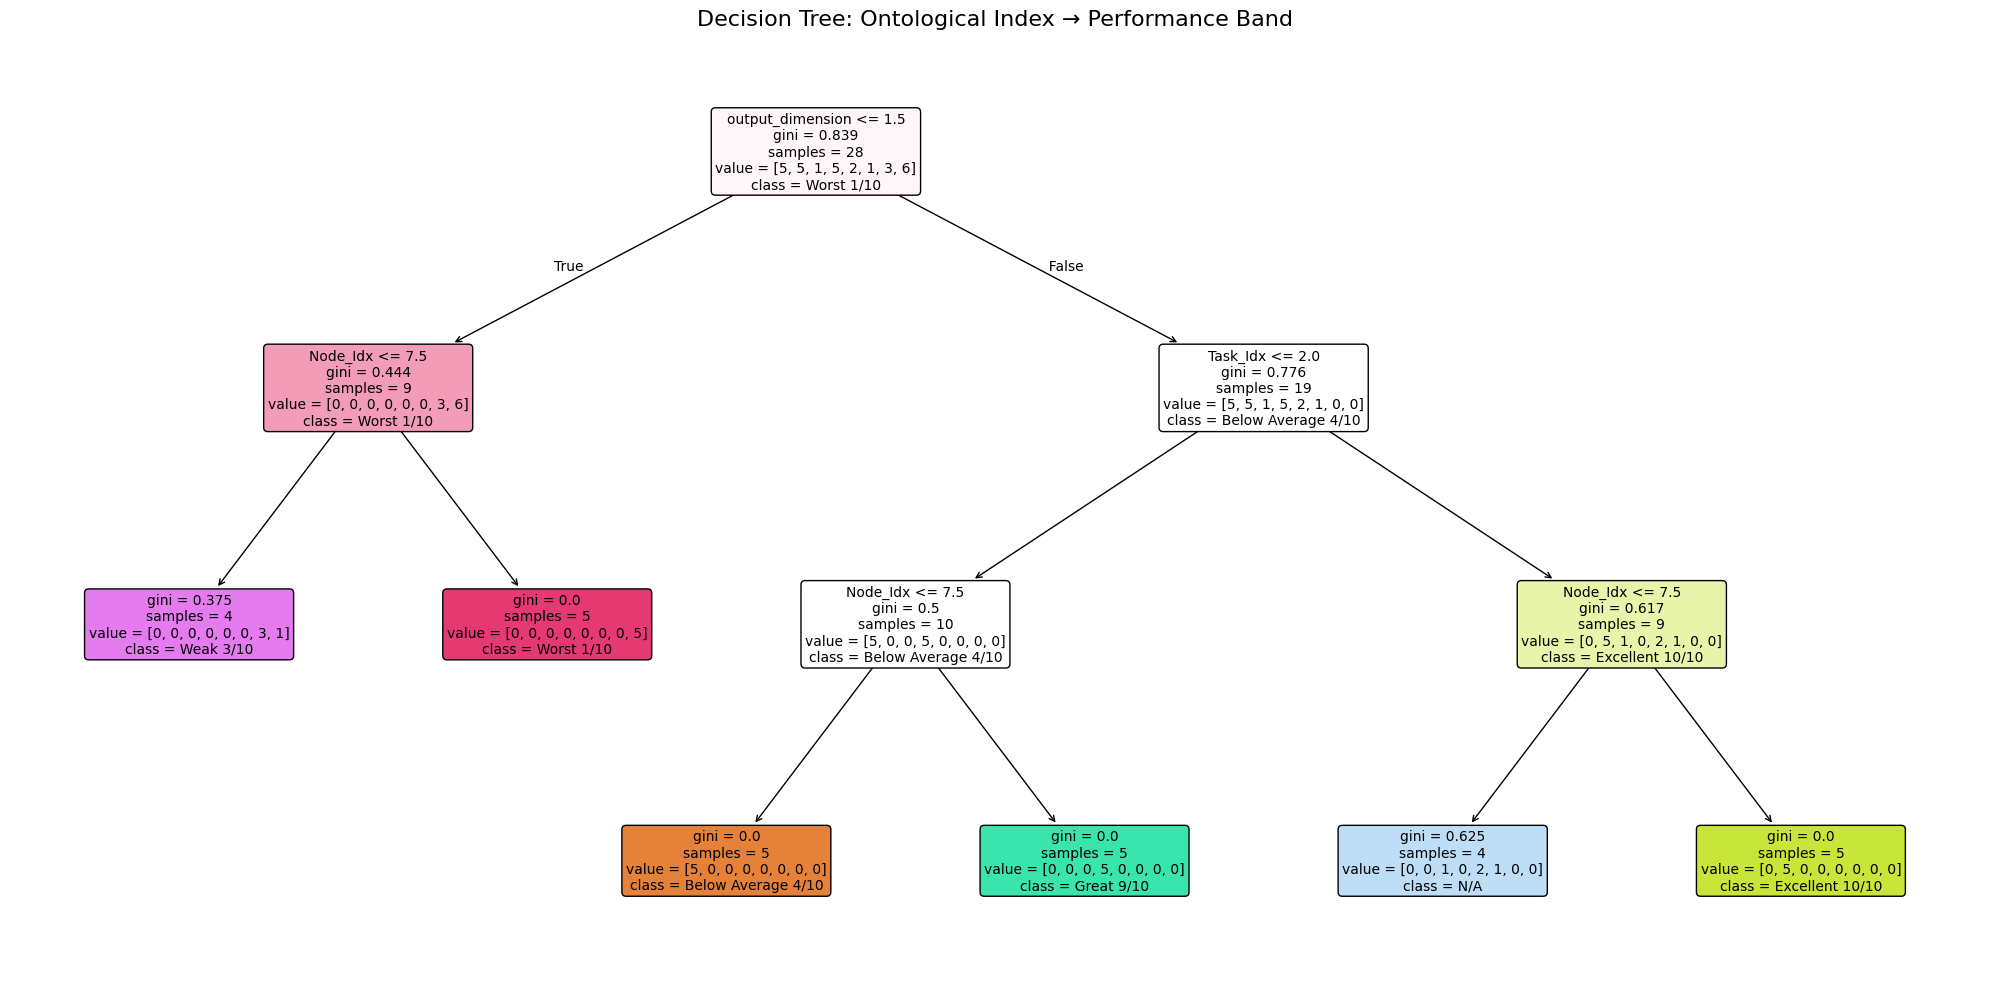

✅ Decision tree saved to output\run_20260323_113858\subset_01\analysis\decision_tree.png

✅ Meta-analysis complete


PIPELINE COMPLETE

ALL SUBSET RUNS COMPLETE
Results in: output/run_20260323_113858/


In [13]:
# ── Cell 8: Full run ─────────────────────────────────────────────────────────
# Results stream to disk after every experiment.
# Epoch log streams to analysis/epoch_log.csv if save_training_history=True.
# If interrupted, all completed experiments are already saved.

for subset_idx, subset_path in enumerate(subset_paths):
    print(f"\n{'='*80}")
    print(f'SUBSET RUN {subset_idx + 1}/{N_SUBSETS}  —  {subset_path}')
    print(f"{'='*80}")
    config = {
        **BASE_CONFIG,
        'data_path': subset_path,
        'embedding_dir': f'{SUBSETS_DIR}/embeddings_{subset_idx:02d}',
        'output_dir': f'{BASE}output/run_{run_id}/subset_{subset_idx:02d}',
    }
    try:
        OntologicalExperimentPipeline(config).run()
    except Exception as e:
        print(f'⚠ Subset {subset_idx} run failed: {e}')
        continue

print(f"\n{'='*80}")
print('ALL SUBSET RUNS COMPLETE')
print(f'Results in: {BASE}output/run_{run_id}/')
print(f"{'='*80}")


Decision Tree Training Results
Features: ['Task_Idx', 'Node_Idx', 'Edge_Idx', 'Text_Idx', 'number_of_nodes', 'avg_text_length', 'text_vocab_entropy', 'label_balance_entropy', 'output_dimension']
Target: Performance_Band
Train Accuracy: 0.893
Test Accuracy: 0.625
Tree Depth: 3
Number of Leaves: 6

  Task_Idx: 0.214
  Node_Idx: 0.541
  Edge_Idx: 0.000
  Text_Idx: 0.000
  number_of_nodes: 0.000
  avg_text_length: 0.000
  text_vocab_entropy: 0.000
  label_balance_entropy: 0.000
  output_dimension: 0.244

Decision Tree Training Results
Features: ['Task_Idx', 'Node_Idx', 'Edge_Idx', 'Text_Idx']
Target: Performance_Band
Train Accuracy: 0.893
Test Accuracy: 0.625
Tree Depth: 3
Number of Leaves: 6

  Task_Idx: 0.459
  Node_Idx: 0.541
  Edge_Idx: 0.000
  Text_Idx: 0.000
✅ Decision tree plot saved to original_tree.png


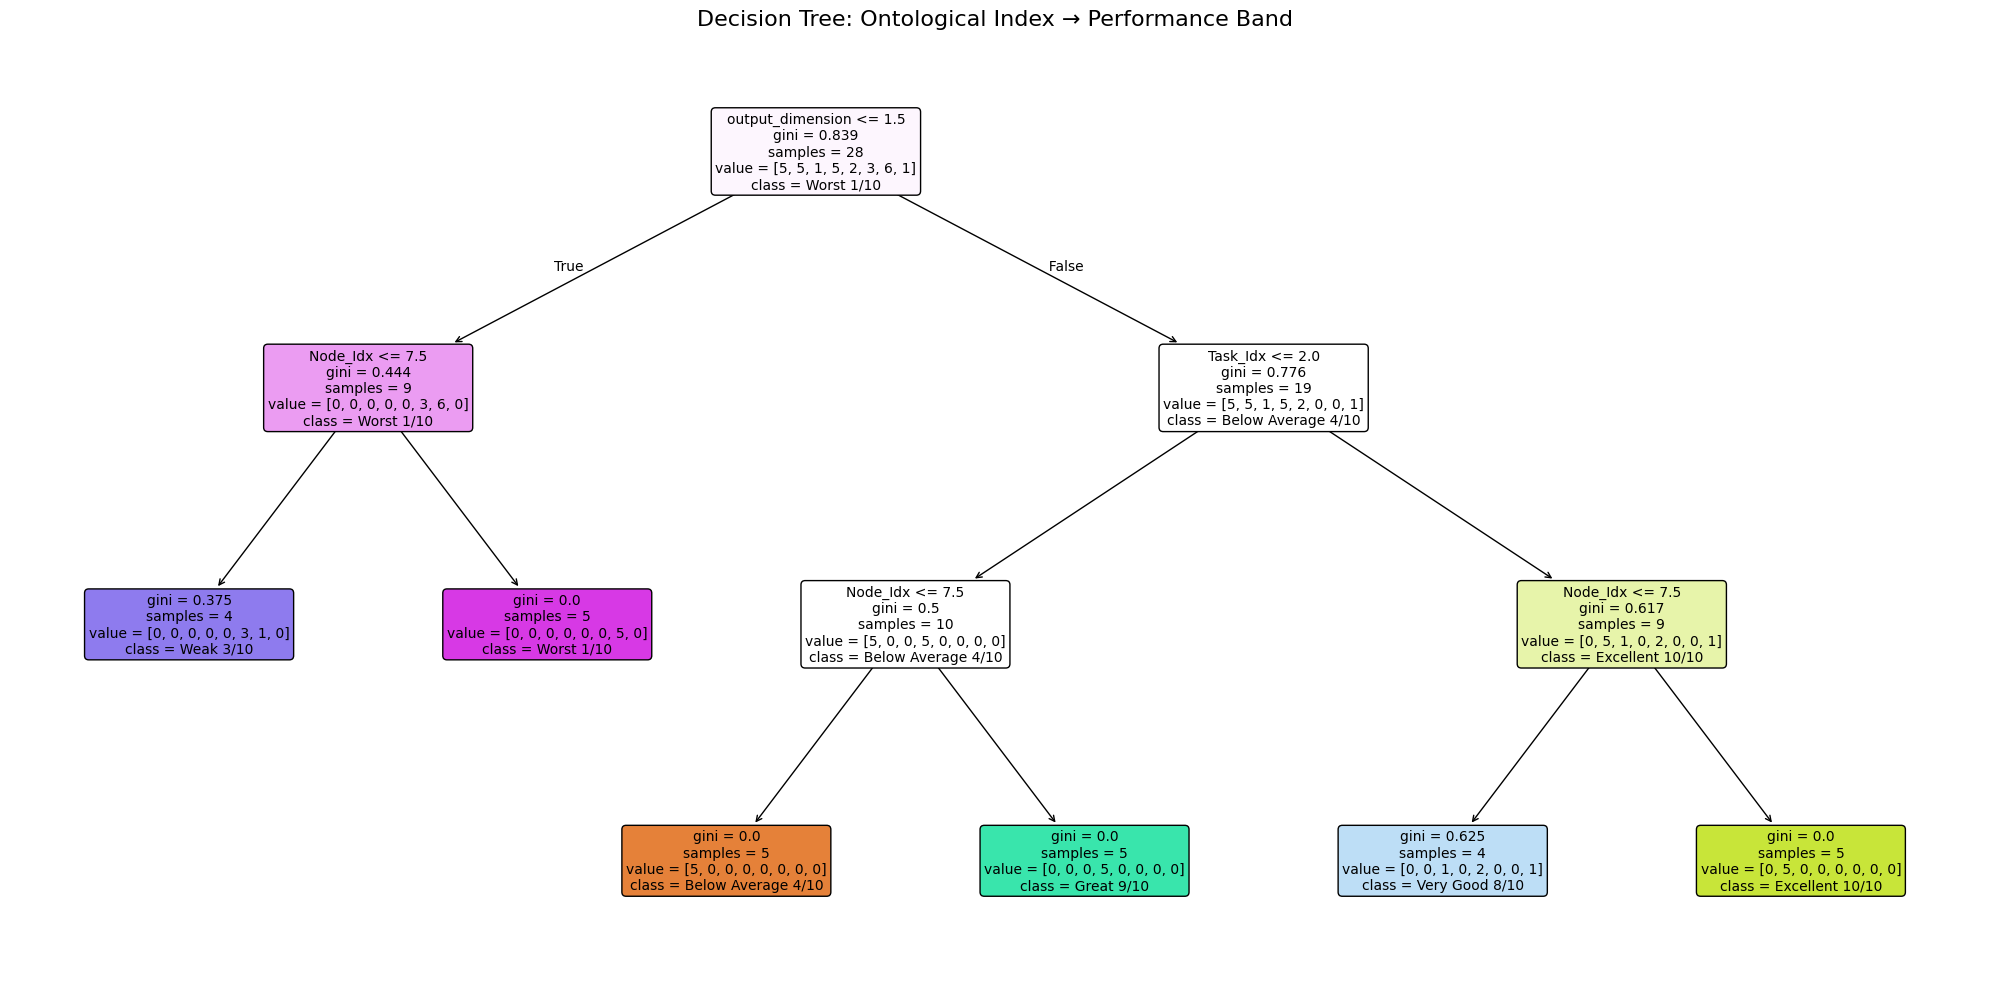

✅ Decision tree plot saved to case_tree.png


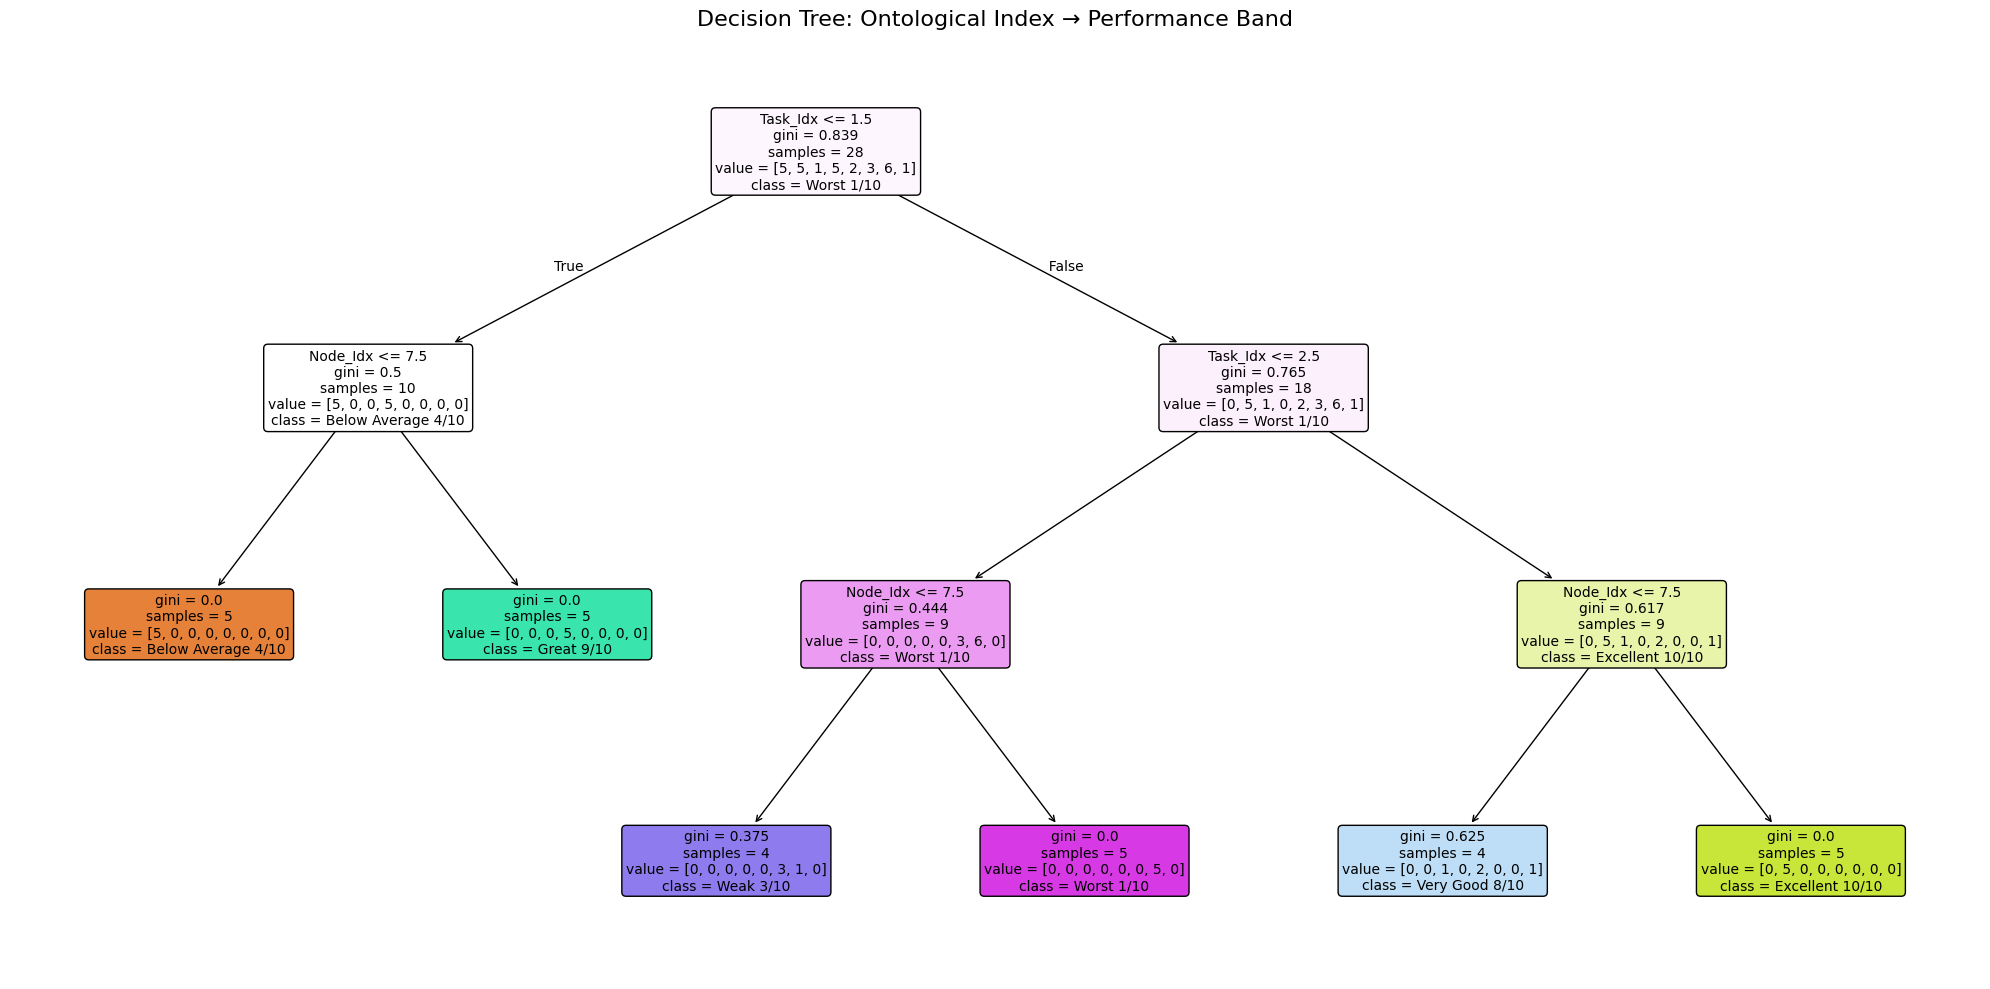

In [18]:
case_of_interest = r"output\run_20260323_113858\subset_01\analysis\decision_tree_table.csv"
df_original = pd.read_csv(case_of_interest)
df_case = pd.read_csv(case_of_interest)

# remove columns "number_of_nodes,avg_text_length,text_vocab_entropy,label_balance_entropy,task_type,output_dimension""main (1).ipynb"
columns_to_remove = [
    'number_of_nodes', 'avg_text_length', 'text_vocab_entropy',
    'label_balance_entropy', 'task_type', 'output_dimension'
]
df_case_reduced = df_case.drop(columns=columns_to_remove)

# compare decision tree plot results with and without the additional stats columns
from analyzer import DecisionTreeAnalyzer

analyzer_original = DecisionTreeAnalyzer()
analyzer_original.dt_table = df_original
analyzer_original.train_decision_tree(
    target_metric='Performance_Band',
    max_depth=5,
    min_samples_split=5
)

analyzer_case = DecisionTreeAnalyzer()
analyzer_case.dt_table = df_case_reduced
analyzer_case.train_decision_tree(
    target_metric='Performance_Band',
    max_depth=5,
    min_samples_split=5
)

# def plot_decision_tree(self, figsize: tuple = (20, 10), 
#                           fontsize: int = 10, save_path: Optional[str] = None):
    
analyzer_original.plot_decision_tree(
    save_path='original_tree.png'
)

analyzer_case.plot_decision_tree(
    save_path='case_tree.png'
)

In [22]:
# ── Cell 9a: ValidationProtocol class definition ──────────────────────────────
import json
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

class ValidationProtocol:
    """
    Orchestrates comprehensive validation of meta-prediction reliability.
    
    Phases:
    1. Blind: Use trained DecisionTreeAnalyzer to predict performance bands
    2. GNN: Execute full training pipeline on validation set for ground truth
    3. Validate: Compare predicted vs actual, compute confusion matrix, analyze drift
    """
    
    def __init__(self, validation_data_path: str, base_config: Dict, 
                 analyzer: DecisionTreeAnalyzer, base_output_dir: str):
        """
        Args:
            validation_data_path: Path to arxiv_subset_50k.jsonl
            base_config: Configuration template (will be adapted per experiment)
            analyzer: Trained DecisionTreeAnalyzer with predict_performance method
            base_output_dir: Root output directory
        """
        self.validation_data_path = validation_data_path
        self.base_config = base_config
        self.analyzer = analyzer
        self.base_output_dir = Path(base_output_dir) / 'validation_results'
        self.base_output_dir.mkdir(exist_ok=True, parents=True)
        
        # Validation structures
        self.validation_set = None
        self.validation_stats = None
        self.predictions = []  # Meta-predictions
        self.ground_truths = []  # GNN results
        self.confusion_data = []  # For confusion matrix
        
    def load_validation_data(self):
        """Load and analyze the disjoint validation set."""
        print('\n' + '='*80)
        print('VALIDATION PHASE 0: DATA ISOLATION & ANALYSIS')
        print('='*80)
        
        # Load validation data using ArxivDataManager
        self.validation_set = ArxivDataManager(
            data_path=self.validation_data_path,
            subset_size=None
        )
        self.validation_set.load_data()
        self.validation_set.extract_unique_authors()
        
        # Compute statistics for drift analysis
        df = self.validation_set.df
        all_words = []
        for row in df.itertuples():
            text = f"{getattr(row, 'title', '') or ''} {getattr(row, 'abstract', '') or ''}"
            all_words.extend(text.lower().split())
        
        counts = Counter(all_words)
        total_words = sum(counts.values())
        text_vocab_entropy = -sum(
            (c / total_words) * math.log2(c / total_words) for c in counts.values()
        )
        
        label_counts = df['cat_top'].value_counts()
        label_probs = label_counts / label_counts.sum()
        label_balance_entropy = -sum(p * math.log2(p) for p in label_probs)
        
        avg_text_length = np.mean([
            len(str(getattr(row, 'title', '') or '')) + 
            len(str(getattr(row, 'abstract', '') or ''))
            for row in df.itertuples()
        ])
        
        self.validation_stats = {
            'num_records': len(df),
            'num_authors': len(self.validation_set.author_list),
            'avg_text_length': round(float(avg_text_length), 4),
            'text_vocab_entropy': float(text_vocab_entropy),
            'label_balance_entropy': float(label_balance_entropy),
            'category_distribution': df['cat_top'].value_counts().to_dict()
        }
        
        print(f"✅ Validation set loaded: {self.validation_stats['num_records']} records")
        print(f"   Authors: {self.validation_stats['num_authors']}")
        print(f"   Text vocab entropy: {self.validation_stats['text_vocab_entropy']:.4f}")
        print(f"   Label balance entropy: {self.validation_stats['label_balance_entropy']:.4f}")
        return self.validation_stats
    
    def generate_standard_ontological_space(self) -> List[Dict]:
        """
        Generate 40 standard ontological variants:
        1 Task × 2 Nodes × 2 Edges × 2 Text Fidelities × 5 Similarity Thresholds
        
        Returns:
            List of 40 experiment configurations
        """
        task_indices = [1]  # Standard task
        node_indices = [7, 8]  # Paper and author
        edge_indices = [10, 11]  # Two edge types
        text_indices = ['a', 'e']  # Best and worst text fidelity
        similarity_thresholds = ['a', 'b', 'c', 'd', 'e']  # 5 thresholds
        
        space = []
        for task_idx in task_indices:
            for node_idx in node_indices:
                for edge_idx in edge_indices:
                    for text_idx in text_indices:
                        if edge_idx == 11:
                            # Edge type 11 requires threshold
                            for threshold in similarity_thresholds:
                                space.append({
                                    'task_idx': task_idx,
                                    'node_idx': node_idx,
                                    'edge_idx': edge_idx,
                                    'text_idx': text_idx,
                                    'similarity_threshold': threshold
                                })
                        else:
                            # Edge type 10 doesn't use threshold
                            space.append({
                                'task_idx': task_idx,
                                'node_idx': node_idx,
                                'edge_idx': edge_idx,
                                'text_idx': text_idx,
                                'similarity_threshold': None
                            })
        
        print(f"\n{'='*80}")
        print(f"STANDARD ONTOLOGICAL SPACE: {len(space)} variants")
        print(f"{'='*80}")
        print(f"1 Task × 2 Nodes × 2 Edges × 2 Text Fidelities × 5 Thresholds = {len(space)}")
        print(f"{'='*80}\n")
        return space
    
    def run_meta_prediction_phase(self, space: List[Dict]):
        """
        PHASE 1 (Blind): Use trained DecisionTreeAnalyzer to predict performance.
        
        Args:
            space: List of experiment configurations
        """
        print('\n' + '='*80)
        print('VALIDATION PHASE 1: META-PREDICTION (BLIND)')
        print('='*80)
        
        self.predictions = []
        for i, config in enumerate(space):
            try:
                predicted_band = self.analyzer.predict_performance(
                    task_idx=config['task_idx'],
                    node_idx=config['node_idx'],
                    edge_idx=config['edge_idx'],
                    text_idx=config['text_idx']
                )
                
                pred_record = {
                    'variant_idx': i,
                    **config,
                    'predicted_band': predicted_band
                }
                self.predictions.append(pred_record)
                print(f"  [{i+1:2d}/{len(space)}] T{config['task_idx']}_N{config['node_idx']}_"
                      f"E{config['edge_idx']}_X{config['text_idx']} -> {predicted_band}")
            except Exception as e:
                print(f"  ⚠ Prediction {i+1} failed: {e}")
                self.predictions.append({
                    'variant_idx': i,
                    **config,
                    'predicted_band': 'ERROR'
                })
        
        print(f'\n✅ Meta-predictions complete: {len(self.predictions)} variants')
        return self.predictions
    
    def run_ground_truth_phase(self, space: List[Dict], 
                               use_precomputed: bool = False,
                               run_prefix: str = 'validation'):
        """
        PHASE 2 (GNN): Run full training pipeline on validation set for each variant.
        
        Args:
            space: List of experiment configurations
            use_precomputed: Whether to use precomputed embeddings
            run_prefix: Prefix for output directory
        """
        print('\n' + '='*80)
        print('VALIDATION PHASE 2: GROUND TRUTH (GNN TRAINING)')
        print('='*80)
        
        embedding_dir = str(self.base_output_dir / 'validation_embeddings')
        os.makedirs(embedding_dir, exist_ok=True)
        
        # Compute/load embeddings once for validation set
        if use_precomputed and os.path.exists(f'{embedding_dir}/article_embeddings.npy'):
            print("Loading precomputed embeddings...")
            self.validation_set.load_embeddings(
                input_dir=embedding_dir,
                prefix='validation'
            )
        else:
            print("Computing embeddings...")
            self.validation_set.compute_embeddings(
                model_name=self.base_config.get('sbert_model', 'all-MiniLM-L6-v2'),
                text_fidelity='super',
                force_recompute=False
            )
            self.validation_set.save_embeddings(
                output_dir=embedding_dir,
                prefix='validation'
            )
        
        # Run experiments
        self.ground_truths = []
        tag_builder = TAGBuilder(self.validation_set)
        performance_tracker = PerformanceTracker()
        pipeline = TrainingPipeline(
            model_factory=lambda **kwargs: ModelFactory.create_model(
                model_type=self.base_config.get('model_type', 'sage'),
                **{k: v for k, v in kwargs.items() if k != 'model_type'}
            ),
            device=self.base_config.get('device', 'cuda' if torch.cuda.is_available() else 'cpu')
        )
        
        for i, config in enumerate(space):
            print(f"\n{'#'*80}")
            print(f"GROUND TRUTH EXPERIMENT {i+1}/{len(space)}")
            print(f"T{config['task_idx']}_N{config['node_idx']}_E{config['edge_idx']}_"
                  f"X{config['text_idx']}", end="")
            if config['similarity_threshold']:
                print(f"_S{config['similarity_threshold']}")
            else:
                print()
            print(f"{'#'*80}")
            
            try:
                # Build TAG
                tag = tag_builder.build(
                    task_idx=config['task_idx'],
                    node_idx=config['node_idx'],
                    edge_idx=config['edge_idx'],
                    text_idx=config['text_idx'],
                    similarity_threshold=config['similarity_threshold']
                )
                
                # Get labels and output dimension based on task
                num_classes = self.validation_set.num_classes or self.base_config.get('num_classes', 10)
                task_idx = config['task_idx']
                
                if config['node_idx'] == 8:
                    embeddings = self.validation_set.author_embeddings
                    node_list = self.validation_set.author_list
                    node_type = 'author'
                else:
                    embeddings = self.validation_set.article_embeddings
                    node_list = list(self.validation_set.df['id'])
                    node_type = 'paper'
                
                if task_idx == 1:
                    if node_type == 'author':
                        labels = self.validation_set.get_author_category_labels(num_classes=num_classes)
                    else:
                        labels = self.validation_set.get_category_labels(num_classes=num_classes)
                    output_dimension = num_classes
                    stats_task_type = 'node_categorical'
                else:
                    raise NotImplementedError(f'Validation currently supports task_idx=1 only')
                
                embeddings = normalize(embeddings, axis=1).astype(np.float32)
                
                # Run training
                model_config = {
                    'hidden_dim': self.base_config.get('hidden_dim', 256),
                    'dropout': self.base_config.get('dropout', 0.5)
                }
                trainer_config = {
                    'lr': self.base_config.get('lr', 0.001),
                    'weight_decay': self.base_config.get('weight_decay', 5e-4),
                    'epochs': self.base_config.get('epochs', 100),
                    'patience': self.base_config.get('patience', 50)
                }
                
                results = pipeline.run_experiment(
                    tag=tag,
                    embeddings=embeddings,
                    labels=labels,
                    node_list=node_list,
                    num_classes=output_dimension,
                    model_config=model_config,
                    trainer_config=trainer_config,
                    save_model_path=None,
                    save_training_history=False
                )
                
                # Compute stats
                G = tag.graph
                all_words = []
                for row in self.validation_set.df.itertuples():
                    text = f"{getattr(row, 'title', '') or ''} {getattr(row, 'abstract', '') or ''}"
                    all_words.extend(text.lower().split())
                counts = Counter(all_words)
                total_words = sum(counts.values())
                text_vocab_entropy = -sum(
                    (c / total_words) * math.log2(c / total_words) for c in counts.values()
                )
                label_counts = self.validation_set.df['cat_top'].value_counts()
                label_probs = label_counts / label_counts.sum()
                label_balance_entropy = -sum(p * math.log2(p) for p in label_probs)
                avg_text_length = np.mean([
                    len(str(getattr(row, 'title', '') or '')) + 
                    len(str(getattr(row, 'abstract', '') or ''))
                    for row in self.validation_set.df.itertuples()
                ])
                
                results['stats'] = {
                    'number_of_nodes': G.number_of_nodes(),
                    'avg_text_length': round(float(avg_text_length), 4),
                    'text_vocab_entropy': text_vocab_entropy,
                    'label_balance_entropy': float(label_balance_entropy),
                    'task_type': stats_task_type,
                    'output_dimension': output_dimension,
                    'normalized_score': float(results['test_metrics'].get('top1', np.nan))
                }
                
                # Categorize actual band
                actual_band = PerformanceBand.categorize_accuracy(
                    float(results['test_metrics'].get('top1', np.nan))
                )
                
                ground_truth_record = {
                    'variant_idx': i,
                    **config,
                    'actual_band': actual_band,
                    'top1_accuracy': float(results['test_metrics'].get('top1', np.nan)),
                    **results['test_metrics']
                }
                self.ground_truths.append(ground_truth_record)
                
                print(f"✅ Exp {i+1} complete: {actual_band} (Top1: {ground_truth_record['top1_accuracy']:.4f})")
                
            except Exception as e:
                print(f"⚠ Ground truth experiment {i+1} failed: {e}")
                self.ground_truths.append({
                    'variant_idx': i,
                    **config,
                    'actual_band': 'ERROR',
                    'top1_accuracy': np.nan
                })
        
        print(f'\n✅ Ground truth phase complete: {len(self.ground_truths)} variants')
        return self.ground_truths
    
    def compute_statistical_validation(self) -> Dict:
        """
        PHASE 3 (Validate): Compare predicted vs actual, compute metrics.
        
        Returns:
            Dictionary with validation statistics
        """
        print('\n' + '='*80)
        print('VALIDATION PHASE 3: STATISTICAL VALIDATION')
        print('='*80)
        
        # Merge predictions and ground truths
        merged = []
        for pred in self.predictions:
            gt = next((g for g in self.ground_truths if g['variant_idx'] == pred['variant_idx']), None)
            if gt:
                merged.append({
                    'variant_idx': pred['variant_idx'],
                    'task_idx': pred['task_idx'],
                    'node_idx': pred['node_idx'],
                    'edge_idx': pred['edge_idx'],
                    'text_idx': pred['text_idx'],
                    'similarity_threshold': pred['similarity_threshold'],
                    'predicted_band': pred['predicted_band'],
                    'actual_band': gt['actual_band'],
                    'top1_accuracy': gt.get('top1_accuracy', np.nan),
                    'match': pred['predicted_band'] == gt['actual_band']
                })
        
        df_merged = pd.DataFrame(merged)
        
        # Meta-accuracy
        valid_matches = df_merged[df_merged['actual_band'] != 'ERROR']
        if len(valid_matches) > 0:
            meta_accuracy = (valid_matches['match'].sum()) / len(valid_matches)
        else:
            meta_accuracy = 0.0
        
        # Confusion matrix
        from sklearn.metrics import confusion_matrix
        try:
            confusion = confusion_matrix(
                valid_matches['actual_band'],
                valid_matches['predicted_band'],
                labels=sorted(valid_matches['actual_band'].unique())
            )
        except:
            confusion = None
        
        # Feature drift analysis
        training_stats = self.analyzer.dt_table[[
            'number_of_nodes', 'text_vocab_entropy', 'label_balance_entropy'
        ]].describe()
        
        drift_analysis = {
            'validation_stats': self.validation_stats,
            'training_stats_mean': {
                'number_of_nodes': float(self.analyzer.dt_table['number_of_nodes'].mean()),
                'text_vocab_entropy': float(self.analyzer.dt_table['text_vocab_entropy'].mean()),
                'label_balance_entropy': float(self.analyzer.dt_table['label_balance_entropy'].mean())
            },
            'training_stats_std': {
                'number_of_nodes': float(self.analyzer.dt_table['number_of_nodes'].std()),
                'text_vocab_entropy': float(self.analyzer.dt_table['text_vocab_entropy'].std()),
                'label_balance_entropy': float(self.analyzer.dt_table['label_balance_entropy'].std())
            }
        }
        
        validation_results = {
            'meta_accuracy': float(meta_accuracy),
            'total_variants': len(df_merged),
            'successful_variants': len(valid_matches),
            'failed_variants': len(df_merged) - len(valid_matches),
            'band_distribution_actual': valid_matches['actual_band'].value_counts().to_dict(),
            'band_distribution_predicted': valid_matches['predicted_band'].value_counts().to_dict(),
            'confusion_matrix': confusion.tolist() if confusion is not None else None,
            'confusion_labels': sorted(valid_matches['actual_band'].unique()) if len(valid_matches) > 0 else [],
            'drift_analysis': drift_analysis
        }
        
        print(f"\n{'='*60}")
        print(f"META-ACCURACY: {meta_accuracy:.1%}")
        print(f"{'='*60}")
        print(f"Successful variants: {len(valid_matches)}/{len(df_merged)}")
        print(f"Correct predictions: {valid_matches['match'].sum()}/{len(valid_matches)}")
        print(f"\nActual band distribution:")
        for band, count in valid_matches['actual_band'].value_counts().items():
            print(f"  {band}: {count}")
        print(f"\nPredicted band distribution:")
        for band, count in valid_matches['predicted_band'].value_counts().items():
            print(f"  {band}: {count}")
        
        return validation_results, df_merged
    
    def generate_validation_report(self, validation_results: Dict, df_merged: pd.DataFrame):
        """
        Generate JSON report and visualizations.
        
        Args:
            validation_results: Validation statistics
            df_merged: Merged predictions and ground truths
        """
        print('\n' + '='*80)
        print('GENERATING VALIDATION REPORT')
        print('='*80)
        
        # Save merged DataFrame as CSV
        csv_path = self.base_output_dir / 'validation_results.csv'
        df_merged.to_csv(csv_path, index=False)
        print(f"✅ Results CSV: {csv_path}")
        
        # Save JSON report
        report_path = self.base_output_dir / 'validation_report.json'
        with open(report_path, 'w') as f:
            json.dump(validation_results, f, indent=2)
        print(f"✅ Validation report: {report_path}")
        
        # Generate visualizations
        fig = plt.figure(figsize=(16, 12))
        gs = GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)
        
        # 1. Meta-accuracy gauge
        ax1 = fig.add_subplot(gs[0, 0])
        meta_acc = validation_results['meta_accuracy']
        colors = ['#d62728' if meta_acc < 0.5 else '#ff7f0e' if meta_acc < 0.7 else '#2ca02c']
        ax1.bar(['Meta-Accuracy'], [meta_acc], color=colors[0], width=0.4)
        ax1.set_ylim([0, 1])
        ax1.set_ylabel('Accuracy', fontsize=12)
        ax1.set_title('Meta-Prediction Accuracy', fontsize=13, fontweight='bold')
        ax1.text(0, meta_acc + 0.05, f'{meta_acc:.1%}', ha='center', fontsize=14, fontweight='bold')
        ax1.grid(axis='y', alpha=0.3)
        
        # 2. Variant success rate
        ax2 = fig.add_subplot(gs[0, 1])
        success = validation_results['successful_variants']
        failed = validation_results['failed_variants']
        ax2.pie([success, failed], labels=['Successful', 'Failed'], autopct='%1.1f%%',
                colors=['#2ca02c', '#d62728'], startangle=90)
        ax2.set_title(f'Variant Completion\n({success}/{success+failed})', 
                     fontsize=13, fontweight='bold')
        
        # 3. Actual band distribution
        ax3 = fig.add_subplot(gs[1, 0])
        actual_dist = validation_results['band_distribution_actual']
        bands = list(actual_dist.keys())
        counts = list(actual_dist.values())
        ax3.barh(bands, counts, color='steelblue')
        ax3.set_xlabel('Count', fontsize=11)
        ax3.set_title('Actual Performance Band Distribution', fontsize=13, fontweight='bold')
        ax3.grid(axis='x', alpha=0.3)
        
        # 4. Predicted band distribution
        ax4 = fig.add_subplot(gs[1, 1])
        pred_dist = validation_results['band_distribution_predicted']
        bands = list(pred_dist.keys())
        counts = list(pred_dist.values())
        ax4.barh(bands, counts, color='coral')
        ax4.set_xlabel('Count', fontsize=11)
        ax4.set_title('Predicted Performance Band Distribution', fontsize=13, fontweight='bold')
        ax4.grid(axis='x', alpha=0.3)
        
        # 5. Confusion matrix (if available)
        if validation_results['confusion_matrix'] is not None:
            ax5 = fig.add_subplot(gs[2, :])
            cm = np.array(validation_results['confusion_matrix'])
            labels = validation_results['confusion_labels']
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5,
                       xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Count'})
            ax5.set_xlabel('Predicted Band', fontsize=11)
            ax5.set_ylabel('Actual Band', fontsize=11)
            ax5.set_title('Confusion Matrix: Predicted vs. Actual Performance Bands', 
                         fontsize=13, fontweight='bold')
        
        # Save visualization
        viz_path = self.base_output_dir / 'validation_visualization.png'
        plt.savefig(viz_path, dpi=300, bbox_inches='tight')
        print(f"✅ Visualization: {viz_path}")
        plt.show()
        
        print(f"\n{'='*60}")
        print(f"VALIDATION REPORT GENERATED")
        print(f"Output directory: {self.base_output_dir}")
        print(f"{'='*60}\n")

In [25]:
# ── Cell 9b: Initialize and load validation data ──────────────────────────────
# IMPORTANT: This cell requires that the decision tree analyzer has already been 
# trained on a previous run (from Cell 8). If no tree exists, this validation 
# will fail with an error about "No trained decision tree".

VALIDATION_DATA_PATH = BASE + 'data/arxiv_subset_50k.jsonl'
VALIDATION_RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')

# load analyzer with trained decision tree from previous run
previous_run_id = "run_20260323_113858"
analyzer = DecisionTreeAnalyzer()
try:
    analyzer.load_analysis(f'{BASE}output/{previous_run_id}/subset_00/analysis')
    print(f" Loaded DecisionTreeAnalyzer from run {previous_run_id}")

    # /subset_00/analysis/decision_tree_table.csv
    decision_tree_table = pd.read_csv(f'{BASE}output/{previous_run_id}/subset_00/analysis/decision_tree_table.csv')
    # train decision tree on this table
    analyzer.dt_table = decision_tree_table
    analyzer.train_decision_tree(
        target_metric='Performance_Band',
        max_depth=8,
        min_samples_split=8
    )
except Exception as e:
    pass

# Verify the analyzer has a trained decision tree
if analyzer.decision_tree is None:
    print("  WARNING: No trained decision tree found!")
    print("   Please run Cell 8 first to train the DecisionTreeAnalyzer.")
    print("   Then come back to this section.")
else:
    print(f" Decision tree loaded and ready for validation")
    print(f"   Tree depth: {analyzer.decision_tree.get_depth()}")
    print(f"   Number of leaves: {analyzer.decision_tree.get_n_leaves()}")
    
# Initialize validation protocol
validator = ValidationProtocol(
    validation_data_path=VALIDATION_DATA_PATH,
    base_config=BASE_CONFIG,
    analyzer=analyzer,
    base_output_dir=f'{BASE}output/run_{VALIDATION_RUN_ID}'
)

# Load and analyze validation set
print(f"\nValidation data path: {VALIDATION_DATA_PATH}")
validator.load_validation_data()
print(f"Validation output directory: {validator.base_output_dir}")

✅ Analysis loaded from output\run_20260323_113858\subset_00\analysis
 Loaded DecisionTreeAnalyzer from run run_20260323_113858

Decision Tree Training Results
Features: ['Task_Idx', 'Node_Idx', 'Edge_Idx', 'Text_Idx', 'number_of_nodes', 'avg_text_length', 'text_vocab_entropy', 'label_balance_entropy', 'output_dimension']
Target: Performance_Band
Train Accuracy: 0.750
Test Accuracy: 0.750
Tree Depth: 3
Number of Leaves: 6

  Task_Idx: 0.188
  Node_Idx: 0.519
  Edge_Idx: 0.000
  Text_Idx: 0.000
  number_of_nodes: 0.000
  avg_text_length: 0.000
  text_vocab_entropy: 0.000
  label_balance_entropy: 0.000
  output_dimension: 0.293
 Decision tree loaded and ready for validation
   Tree depth: 3
   Number of leaves: 6

Validation data path: data/arxiv_subset_50k.jsonl

VALIDATION PHASE 0: DATA ISOLATION & ANALYSIS
Loading data from data\arxiv_subset_50k.jsonl...
Parsing categories...
Category mapping: {'astro-ph': 0, 'cond-mat': 1, 'cs': 2, 'gr-qc': 3, 'hep-ex': 4, 'hep-lat': 5, 'hep-ph': 6, '

Extracting authors: 100%|██████████| 50000/50000 [00:00<00:00, 57421.66it/s] 


Computing author category labels...
✅ Found 85324 unique authors
✅ 85324 authors have category labels
✅ Validation set loaded: 50000 records
   Authors: 85324
   Text vocab entropy: 10.9514
   Label balance entropy: 3.4220
Validation output directory: output\run_20260323_124346\validation_results


In [26]:
# ── Cell 9c: Run meta-prediction phase (BLIND) ───────────────────────────────
# Generate the 40 standard ontological variants and predict their performance 
# using the trained DecisionTreeAnalyzer (without running any training).

# Generate standard ontological space (40 variants)
standard_space = validator.generate_standard_ontological_space()

# Run meta-prediction phase (all predictions, no training)
predictions = validator.run_meta_prediction_phase(standard_space)

print(f"\n{'='*60}")
print(f"META-PREDICTION PHASE SUMMARY")
print(f"{'='*60}")
print(f"Total predictions: {len(predictions)}")
print(f"\nPredicted band distribution:")
pred_df = pd.DataFrame(predictions)
for band, count in pred_df['predicted_band'].value_counts().items():
    print(f"  {band}: {count}")
print(f"\nSample predictions (first 5):")
print(pred_df[['task_idx', 'node_idx', 'edge_idx', 'text_idx', 'similarity_threshold', 'predicted_band']].head())


STANDARD ONTOLOGICAL SPACE: 24 variants
1 Task × 2 Nodes × 2 Edges × 2 Text Fidelities × 5 Thresholds = 24


VALIDATION PHASE 1: META-PREDICTION (BLIND)
  ⚠ Prediction 1 failed: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- avg_text_length
- label_balance_entropy
- number_of_nodes
- output_dimension
- text_vocab_entropy

  ⚠ Prediction 2 failed: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- avg_text_length
- label_balance_entropy
- number_of_nodes
- output_dimension
- text_vocab_entropy

  ⚠ Prediction 3 failed: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- avg_text_length
- label_balance_entropy
- number_of_nodes
- output_dimension
- text_vocab_entropy

  ⚠ Prediction 4 failed: The feature names should match those that were passed during fit.
Feature names seen at fit time, 

In [ ]:
# ── Cell 9d: Run ground-truth phase (GNN TRAINING) ──────────────────────────
# WARNING: This is computationally expensive — 40 full training runs on the 50k
# validation set. Estimated time: 2-4 hours on GPU, days on CPU.
# 
# Set epochs_for_validation below to a smaller value for quick testing, or
# comment out this cell and use precomputed results if available.

# Option 1: Run full validation (slow but thorough)
EPOCHS_FOR_VALIDATION = BASE_CONFIG['epochs']  # Use default epochs from config
QUICK_TEST = False  # Set to True to use only 2 epochs for testing

if QUICK_TEST:
    print("⚠️  QUICK TEST MODE: Using only 2 epochs per experiment!")
    validation_config = {
        **BASE_CONFIG,
        'epochs': 2,
        'patience': 1,
        'sbert_model': 'all-MiniLM-L6-v2',  # Fast model for testing
    }
else:
    validation_config = {
        **BASE_CONFIG,
        'epochs': EPOCHS_FOR_VALIDATION,
        'use_precomputed_embeddings': False,
        'save_embeddings': True,
    }

print(f"{'='*80}")
print(f"GROUND TRUTH PHASE CONFIGURATION")
print(f"{'='*80}")
print(f"Epochs per experiment: {validation_config['epochs']}")
print(f"Device: {validation_config['device']}")
print(f"Total variants: {len(standard_space)}")
print(f"Estimated time: {'~30 min' if QUICK_TEST else '~2-4 hours on GPU'}")
print(f"{'='*80}\n")

# Uncomment the following to run ground truth phase:
# ground_truths = validator.run_ground_truth_phase(
#     space=standard_space,
#     use_precomputed=validation_config.get('use_precomputed_embeddings', False),
#     run_prefix=f'validation_{VALIDATION_RUN_ID}'
# )
# print(f"\n✅ Ground truth collection complete")

print("⚠️  Ground truth phase is commented out to prevent accidental execution.")
print("   This phase is computationally expensive (2-4 hours on GPU).")
print("   Uncomment the validator.run_ground_truth_phase() call above to run it.")

In [ ]:
# ── Cell 9e: Statistical validation and reporting ───────────────────────────
# After running the ground-truth phase (Cell 9d), run this cell to compute
# validation metrics and generate the report.
#
# If ground_truths is empty, this cell will alert you that Cell 9d needs to run first.

if len(validator.ground_truths) == 0:
    print("⚠️  No ground truth data found!")
    print("   Please run Cell 9d (ground-truth phase) first.")
    print("   Once complete, return to this cell to generate the validation report.")
else:
    # Compute statistical validation
    validation_results, df_merged = validator.compute_statistical_validation()
    
    # Generate report and visualizations
    validator.generate_validation_report(validation_results, df_merged)
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print(f"DRIFT ANALYSIS: Feature Shift Detection")
    print(f"{'='*80}")
    drift = validation_results['drift_analysis']
    
    print(f"\nValidation Set Statistics:")
    print(f"  Records: {drift['validation_stats']['num_records']}")
    print(f"  Authors: {drift['validation_stats']['num_authors']}")
    print(f"  Avg text length: {drift['validation_stats']['avg_text_length']:.2f}")
    print(f"  Text vocab entropy: {drift['validation_stats']['text_vocab_entropy']:.4f}")
    print(f"  Label balance entropy: {drift['validation_stats']['label_balance_entropy']:.4f}")
    
    print(f"\nTraining Set Statistics (mean ± std):")
    train_stats = drift['training_stats_mean']
    train_std = drift['training_stats_std']
    print(f"  Avg text length: {train_stats['avg_text_length']:.2f} ± {train_std['avg_text_length']:.2f}")
    print(f"  Text vocab entropy: {train_stats['text_vocab_entropy']:.4f} ± {train_std['text_vocab_entropy']:.4f}")
    print(f"  Label balance entropy: {train_stats['label_balance_entropy']:.4f} ± {train_std['label_balance_entropy']:.4f}")
    
    # Calculate drift magnitude
    val_entropy = drift['validation_stats']['text_vocab_entropy']
    train_entropy = train_stats['text_vocab_entropy']
    entropy_shift = abs(val_entropy - train_entropy) / max(train_entropy, 0.001)
    
    print(f"\nDrift Magnitude:")
    print(f"  Text entropy shift: {entropy_shift:.1%}")
    if entropy_shift > 0.1:
        print(f"  ⚠️  MODERATE DRIFT DETECTED - Tree may have reduced reliability")
    else:
        print(f"  ✅ Minimal drift - Distribution is stable")
    
    print(f"\n{'='*80}")

In [ ]:
# ── Cell 9f: Detailed mismatch analysis and insights ───────────────────────
# Analyze which configurations were mispredicted and why.
# This helps identify model blind spots and areas for improvement.

if len(validator.ground_truths) == 0:
    print("⚠️  No ground truth data available. Please complete Cell 9d first.")
else:
    print('\n' + '='*80)
    print('DETAILED MISMATCH ANALYSIS')
    print('='*80)
    
    # Merge predictions and ground truths
    merged = []
    for pred in validator.predictions:
        gt = next((g for g in validator.ground_truths if g['variant_idx'] == pred['variant_idx']), None)
        if gt and gt['actual_band'] != 'ERROR':
            merged.append({
                'variant_idx': pred['variant_idx'],
                'task_idx': pred['task_idx'],
                'node_idx': pred['node_idx'],
                'edge_idx': pred['edge_idx'],
                'text_idx': pred['text_idx'],
                'threshold': pred['similarity_threshold'],
                'predicted': pred['predicted_band'],
                'actual': gt['actual_band'],
                'accuracy': gt.get('top1_accuracy', np.nan),
                'match': pred['predicted_band'] == gt['actual_band']
            })
    
    df_analysis = pd.DataFrame(merged)
    
    # 1. Over-optimistic predictions
    print(f"\n{'─'*80}")
    print('OVER-OPTIMISTIC (Predicted Better Than Actual)')
    print(f"{'─'*80}")
    
    band_order = {
        'Excellent 10/10': 10, 'Great 9/10': 9, 'Very Good 8/10': 8, 'Good 7/10': 7,
        'Above Average 6/10': 6, 'Average 5/10': 5, 'Below Average 4/10': 4,
        'Weak 3/10': 3, 'Poor 2/10': 2, 'Worst 1/10': 1, 'N/A': 0
    }
    
    df_analysis['pred_rank'] = df_analysis['predicted'].map(band_order)
    df_analysis['actual_rank'] = df_analysis['actual'].map(band_order)
    
    optimistic = df_analysis[df_analysis['pred_rank'] > df_analysis['actual_rank']]
    if len(optimistic) > 0:
        print(f"\nTotal: {len(optimistic)} variants")
        print("\nTop 5 over-optimistic predictions:")
        for idx, row in optimistic.nlargest(5, 'pred_rank - actual_rank').iterrows():
            print(f"  T{row['task_idx']}_N{row['node_idx']}_E{row['edge_idx']}_X{row['text_idx']} "
                  f"| Pred: {row['predicted']} | Actual: {row['actual']} | "
                  f"Top1: {row['accuracy']:.4f}")
    else:
        print("None found! ✅")
    
    # 2. Over-pessimistic predictions
    print(f"\n{'─'*80}")
    print('OVER-PESSIMISTIC (Predicted Worse Than Actual)')
    print(f"{'─'*80}")
    
    pessimistic = df_analysis[df_analysis['pred_rank'] < df_analysis['actual_rank']]
    if len(pessimistic) > 0:
        print(f"\nTotal: {len(pessimistic)} variants")
        print("\nTop 5 over-pessimistic predictions:")
        for idx, row in pessimistic.nlargest(5, 'actual_rank - pred_rank').iterrows():
            print(f"  T{row['task_idx']}_N{row['node_idx']}_E{row['edge_idx']}_X{row['text_idx']} "
                  f"| Pred: {row['predicted']} | Actual: {row['actual']} | "
                  f"Top1: {row['accuracy']:.4f}")
    else:
        print("None found! ✅")
    
    # 3. Impact by ontological index
    print(f"\n{'─'*80}")
    print('MISMATCH RATE BY ONTOLOGICAL INDEX')
    print(f"{'─'*80}")
    
    print(f"\nBy Node Index:")
    for node_idx in sorted(df_analysis['node_idx'].unique()):
        node_data = df_analysis[df_analysis['node_idx'] == node_idx]
        mismatch_rate = (1 - node_data['match'].mean())
        print(f"  Node {node_idx}: {mismatch_rate:.1%} mismatch rate ({node_data['match'].sum()}/{len(node_data)} correct)")
    
    print(f"\nBy Edge Index:")
    for edge_idx in sorted(df_analysis['edge_idx'].unique()):
        edge_data = df_analysis[df_analysis['edge_idx'] == edge_idx]
        mismatch_rate = (1 - edge_data['match'].mean())
        print(f"  Edge {edge_idx}: {mismatch_rate:.1%} mismatch rate ({edge_data['match'].sum()}/{len(edge_data)} correct)")
    
    print(f"\nBy Text Fidelity:")
    for text_idx in sorted(df_analysis['text_idx'].unique()):
        text_data = df_analysis[df_analysis['text_idx'] == text_idx]
        mismatch_rate = (1 - text_data['match'].mean())
        print(f"  Text {text_idx}: {mismatch_rate:.1%} mismatch rate ({text_data['match'].sum()}/{len(text_data)} correct)")
    
    print(f"\n{'='*80}\n")

## Validation Protocol Summary & Interpretation Guide

### What This Protocol Does

The validation framework tests whether the DecisionTreeAnalyzer's blindly-predicted performance bands 
match the actual performance observed when training GNN models on a held-out validation set.

**Three Phases:**

1. **Phase 1 (Blind Meta-Prediction)**: The trained decision tree predicts performance bands for all 40 variants WITHOUT any GNN training.
   - Fast (seconds)
   - Uses only ontological indices (task, node, edge, text, threshold)
   - Produces predicted bands like "Good 7/10", "Average 5/10", etc.

2. **Phase 2 (Ground Truth GNN)**: Full training pipeline runs on the validation set for all 40 variants.
   - Slow (2-4 hours on GPU)
   - Produces actual Top-1 accuracies that are converted to actual bands
   - Captures real-world performance variability

3. **Phase 3 (Statistical Validation)**: Compare predicted vs. actual to compute:
   - **Meta-Accuracy**: % of variants where predicted band == actual band
   - **Confusion Matrix**: Shows which bands were confused with which
   - **Drift Analysis**: Compares validation set statistics vs. training data
   - **Mismatch Analysis**: Identifies which ontological indices cause problems

### Interpreting Results

- **High Meta-Accuracy (>70%)**: The tree generalizes well to new data
- **Low Meta-Accuracy (<50%)**: The tree may be overfitting or sensitive to data distribution
- **Over-optimistic mismatches**: Tree predicts better performance than actual (risky for decision-making)
- **Over-pessimistic mismatches**: Tree predicts worse performance than actual (missed opportunities)

### When to Use Validation

✅ **Use validation if:**
- You want to trust the meta-predictions for resource allocation
- You're deploying the framework in production
- You want to verify the decision tree generalizes beyond training data

⏭️ **Skip validation if:**
- Running quick experiments for exploration
- Working with similar data distributions (low drift)
- Time/compute is very limited (2-4 hour cost for validation)

# Cell 9: Validation Protocol
## Meta-Prediction vs. Ground Truth Comparison

This section implements a comprehensive validation framework to test the DecisionTreeAnalyzer's predictive reliability on a held-out validation set (arxiv_subset_50k.jsonl) that was strictly excluded from training data.

**Three Phases:**
1. **Meta-Prediction (Blind)**: Use trained tree to predict performance bands for 40 standard variants
2. **Ground Truth (GNN)**: Execute full training pipeline on validation set for all 40 variants  
3. **Statistical Validation**: Compare predicted vs. actual bands with confusion matrices and drift analysis